# Task 2: Stock Price Prediction (Short-Term)
**Objective:** Use historical stock data to predict the next day's closing price.

**Dataset:** Yahoo Finance via `yfinance` library

**Model:** Linear Regression + Random Forest Regressor

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Fetch Historical Stock Data

In [2]:
# Select stock ticker — try 'AAPL', 'TSLA', 'GOOGL'
TICKER = 'AAPL'
START_DATE = '2022-01-01'
END_DATE   = '2024-12-31'

# Download data from Yahoo Finance
df = yf.download(TICKER, start=START_DATE, end=END_DATE)
df.dropna(inplace=True)

print(f'Downloaded {len(df)} trading days for {TICKER}')
df.head()

/tmp/ipykernel_594/862775337.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Downloaded 752 trading days for AAPL


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103683,178.955022,173.895982,174.013402,104487900
2022-01-04,175.843246,179.013714,175.275693,178.710370,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600
2022-01-06,168.308487,171.537664,167.956213,168.993460,96904000
2022-01-07,168.474884,170.402605,167.359351,169.179433,86709100


## 2. Feature Engineering

In [3]:
# Use previous day's Open, High, Low, Volume to predict next Close
# Shift Close by -1 to create the target (next day's close)
df['Target'] = df['Close'].shift(-1)

# Add rolling features
df['MA_5']  = df['Close'].rolling(window=5).mean()   # 5-day moving average
df['MA_20'] = df['Close'].rolling(window=20).mean()  # 20-day moving average
df['Price_Change'] = df['Close'].pct_change()        # % daily change

# Drop rows with NaN (from shift and rolling)
df.dropna(inplace=True)

print('Feature columns available:')
print(df.columns.tolist())

Feature columns available:
[('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL'), ('Target', ''), ('MA_5', ''), ('MA_20', ''), ('Price_Change', '')]


## 3. Prepare Data for Training

In [4]:
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_5', 'MA_20', 'Price_Change']

X = df[feature_cols].values
y = df['Target'].values

# Time-series split: 80% train, 20% test (no shuffle — order matters!)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[split:]

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 585, Test size: 147


## 4. Train Models

In [5]:
# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print('Models trained successfully!')

Models trained successfully!


## 5. Evaluation Metrics

In [6]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:25s} | MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f}')

print('Model Performance on Test Set:')
print('-' * 60)
evaluate('Linear Regression',   y_test, lr_preds)
evaluate('Random Forest',       y_test, rf_preds)

Model Performance on Test Set:
------------------------------------------------------------
Linear Regression         | MAE: $2.69 | RMSE: $3.40 | R²: 0.9321
Random Forest             | MAE: $30.73 | RMSE: $33.30 | R²: -5.4907


## 6. Visualize Actual vs Predicted Prices

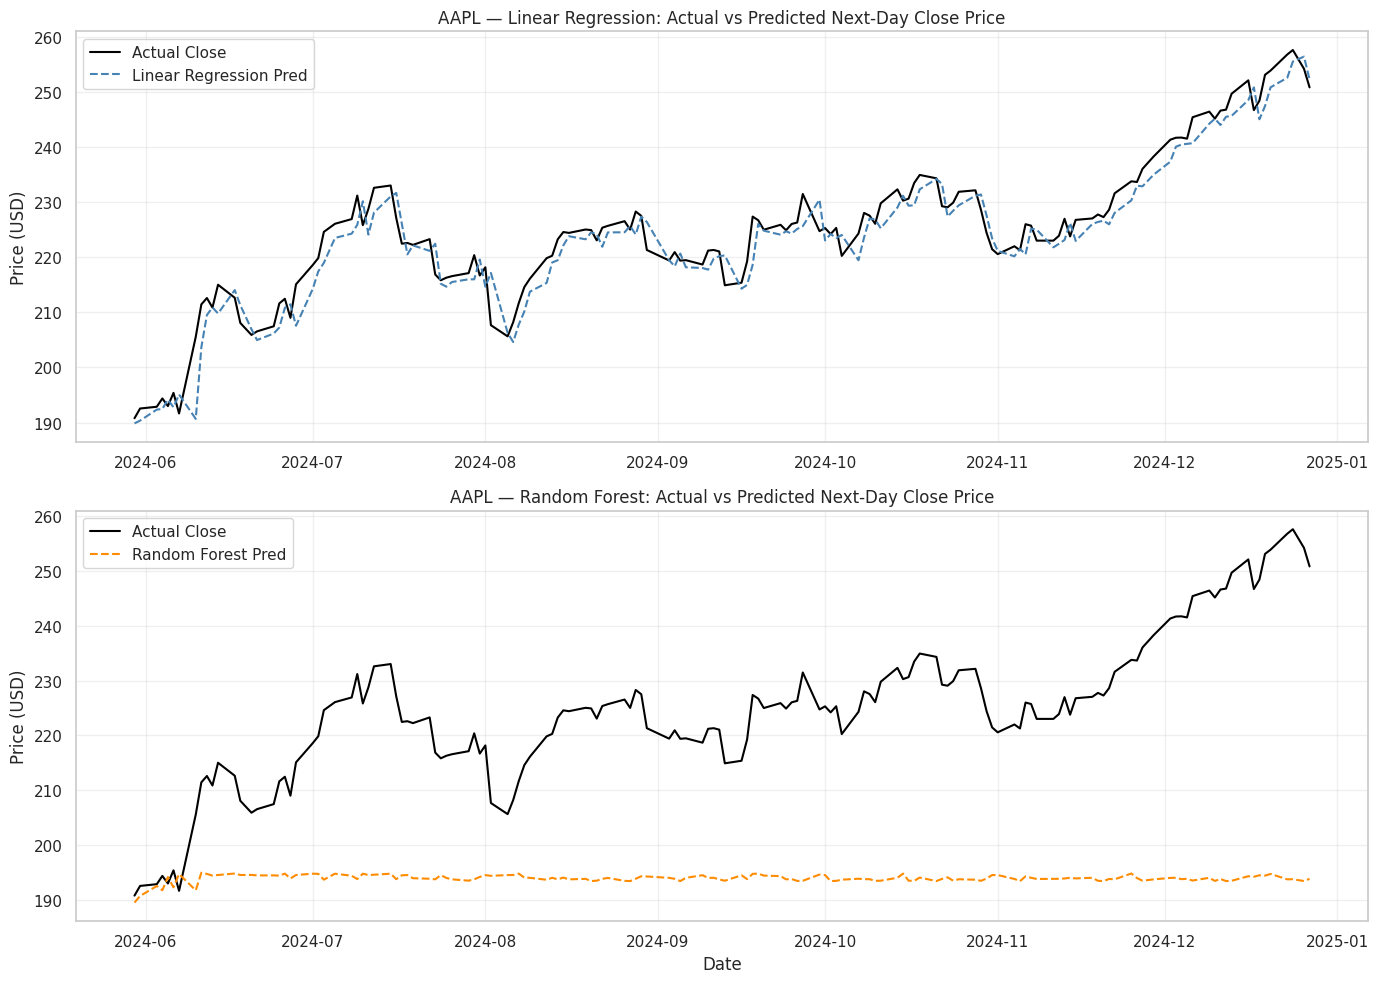

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (preds, label, color) in zip(axes, [
    (lr_preds, 'Linear Regression', 'steelblue'),
    (rf_preds, 'Random Forest',     'darkorange')
]):
    ax.plot(dates_test, y_test,  label='Actual Close',  color='black', linewidth=1.5)
    ax.plot(dates_test, preds,   label=f'{label} Pred', color=color,  linewidth=1.5, linestyle='--')
    ax.set_title(f'{TICKER} — {label}: Actual vs Predicted Next-Day Close Price')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 7. Key Insights

- Both models capture the general price trend well.
- **Random Forest** typically outperforms Linear Regression due to its ability to capture non-linear patterns.
- The biggest challenge is that next-day prices are highly influenced by lagged price — the model is essentially learning a time-shifted version of itself.
- For stronger predictions, consider adding technical indicators (RSI, MACD, Bollinger Bands) or LSTM-based models.